In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import os

Load and clean the dataset

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

df = pd.read_excel(url)

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df = df.dropna(subset=["InvoiceNo", "StockCode", "InvoiceDate", "Quantity", "UnitPrice"])
df = df.drop_duplicates()
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

print("Cleaned Dataset Shape:", df.shape)
display(df.head())

Cleaned Dataset Shape: (524878, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Create pricing dataset

In [3]:
pricing = df.groupby(["StockCode", df["InvoiceDate"].dt.to_period("M")]).agg(
    Price=("UnitPrice", "mean"),
    Demand=("Quantity", "sum"),
    Revenue=("TotalSales", "sum")
).reset_index()

pricing = pricing[(pricing["Price"] > 0) & (pricing["Demand"] > 0)]

print("Pricing Dataset Shape:", pricing.shape)
display(pricing.head())

Pricing Dataset Shape: (34069, 5)


,StockCode,InvoiceDate,Price,Demand,Revenue
0,10002,2010-12,1.201000,251,234.41
1,10002,2011-01,0.962857,340,291.37
2,10002,2011-02,1.072857,52,45.76
3,10002,2011-03,1.142500,28,27.70
4,10002,2011-04,0.850000,189,160.65


Check the pricing data

In [4]:
print("Price Statistics:")
display(pricing[["Price", "Demand", "Revenue"]].describe())

print("Missing Values:")
display(pricing.isnull().sum())

print("Duplicate Rows:", pricing.duplicated().sum())

Price Statistics:


,Price,Demand,Revenue
count,34069.000000,34069.000000,34069.000000
mean,4.725642,163.562770,312.369333
std,95.555125,703.173309,1350.432327
min,0.001000,1.000000,0.001000
25%,1.250000,8.000000,19.540000
50%,2.333333,38.000000,72.010000
75%,4.250000,149.000000,257.150000
max,13541.330000,80995.000000,168469.600000


Missing Values:


,0
StockCode,0
InvoiceDate,0
Price,0
Demand,0
Revenue,0


Duplicate Rows: 0


Estimate price elasticity

In [7]:
pricing["LogPrice"] = np.log(pricing["Price"])
pricing["LogDemand"] = np.log(pricing["Demand"])

X = pricing[["LogPrice"]]
y = pricing["LogDemand"]

model = LinearRegression()
model.fit(X, y)

elasticity = model.coef_[0]
intercept = model.intercept_

print("Estimated Price Elasticity:", round(elasticity, 4))
print("Interpretation: A 1% increase in price is associated with approximately",
      round(abs(elasticity), 2), "% change in demand.")

Estimated Price Elasticity: -0.6177
Interpretation: A 1% increase in price is associated with approximately 0.62 % change in demand.


Price and demand relationship

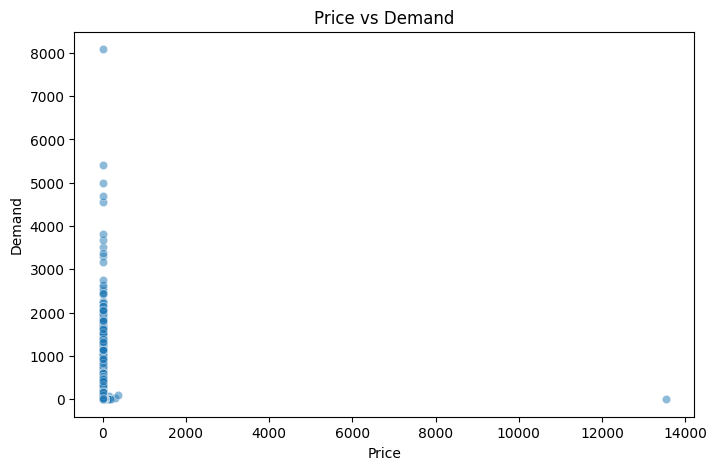

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pricing.sample(min(5000, len(pricing)), random_state=42),
                x="Price", y="Demand", alpha=0.5)
plt.title("Price vs Demand")
plt.xlabel("Price")
plt.ylabel("Demand")
plt.show()

Select a representative product

In [8]:
product_counts = pricing.groupby("StockCode").size()
eligible_products = product_counts[product_counts >= 6].index

product_sales = pricing[pricing["StockCode"].isin(eligible_products)].groupby("StockCode")["Revenue"].sum()

product_id = product_sales.idxmax()

product_data = pricing[pricing["StockCode"] == product_id].copy()

print("Selected Product:", product_id)
print("Historical Observations:", len(product_data))
display(product_data.sort_values("Price").head(10))

Selected Product: DOT
Historical Observations: 13


,StockCode,InvoiceDate,Price,Demand,Revenue,LogPrice,LogDemand
34007,DOT,2011-06,141.055476,84,11848.66,4.949153,4.430817
34006,DOT,2011-05,154.989394,66,10229.30,5.043357,4.189655
34005,DOT,2011-04,160.327234,47,7535.38,5.077217,3.850148
34008,DOT,2011-07,160.512500,80,12841.00,5.078372,4.382027
34003,DOT,2011-02,170.518136,59,10060.57,5.138842,4.077537
34004,DOT,2011-03,179.238030,66,11829.71,5.188715,4.189655
34002,DOT,2011-01,228.226557,61,13921.82,5.430339,4.110874
34010,DOT,2011-09,322.923404,47,15177.40,5.777415,3.850148
34009,DOT,2011-08,372.236667,36,13400.52,5.919530,3.583519
34011,DOT,2011-10,417.561163,43,17955.13,6.034431,3.761200


Historical product information

In [9]:
base_price = product_data["Price"].mean()
base_demand = product_data["Demand"].mean()

print("Average Historical Price:", round(base_price, 2))
print("Average Historical Demand:", round(base_demand, 2))
print("Average Historical Revenue:", round(product_data["Revenue"].mean(), 2))

Average Historical Price: 368.59
Average Historical Demand: 54.31
Average Historical Revenue: 15865.29


Simulate different prices

In [10]:
price_range = np.linspace(base_price * 0.5, base_price * 1.5, 50)

simulated_demand = base_demand * (price_range / base_price) ** elasticity
simulated_revenue = price_range * simulated_demand

simulation = pd.DataFrame({
    "Price": price_range,
    "Expected_Demand": simulated_demand,
    "Expected_Revenue": simulated_revenue
})

display(simulation.head())

,Price,Expected_Demand,Expected_Revenue
0,184.297187,83.331264,15357.717471
1,191.819521,81.297271,15594.403533
2,199.341855,79.388361,15825.423216
3,206.864189,77.592544,16051.118589
4,214.386523,75.899358,16271.799505


Find optimal price

In [11]:
optimal_row = simulation.loc[simulation["Expected_Revenue"].idxmax()]

optimal_price = optimal_row["Price"]
optimal_demand = optimal_row["Expected_Demand"]
optimal_revenue = optimal_row["Expected_Revenue"]

print("Optimal Price:", round(optimal_price, 2))
print("Expected Demand:", round(optimal_demand, 2))
print("Expected Revenue:", round(optimal_revenue, 2))

Optimal Price: 552.89
Expected Demand: 42.28
Expected Revenue: 23373.81


Price vs demand

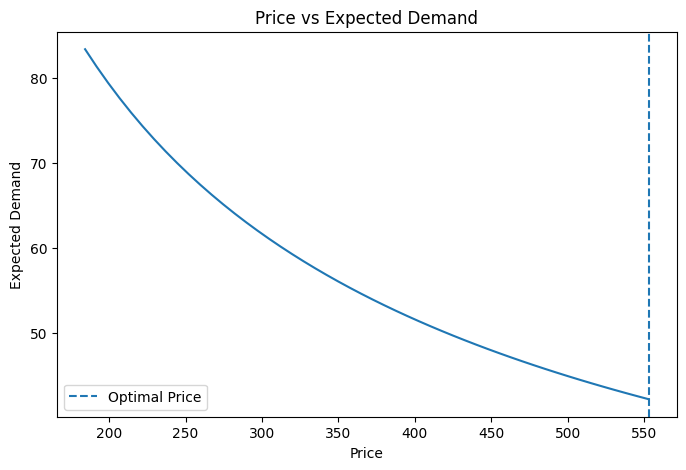

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(simulation["Price"], simulation["Expected_Demand"])
plt.axvline(optimal_price, linestyle="--", label="Optimal Price")
plt.xlabel("Price")
plt.ylabel("Expected Demand")
plt.title("Price vs Expected Demand")
plt.legend()
plt.show()

Price vs revenue

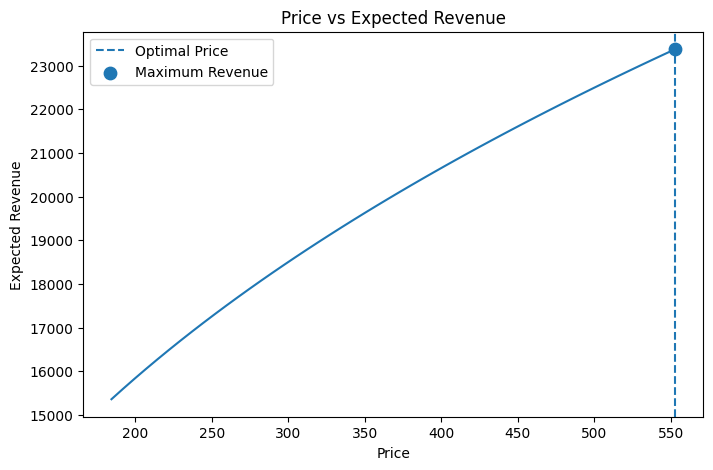

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(simulation["Price"], simulation["Expected_Revenue"])
plt.axvline(optimal_price, linestyle="--", label="Optimal Price")
plt.scatter(optimal_price, optimal_revenue, s=80, label="Maximum Revenue")
plt.xlabel("Price")
plt.ylabel("Expected Revenue")
plt.title("Price vs Expected Revenue")
plt.legend()
plt.show()

Compare current and optimized pricing

In [14]:
current_revenue = base_price * base_demand

comparison = pd.DataFrame({
    "Metric": ["Price", "Expected Demand", "Expected Revenue"],
    "Current": [base_price, base_demand, current_revenue],
    "Optimized": [optimal_price, optimal_demand, optimal_revenue]
})

comparison["Change_%"] = (
    (comparison["Optimized"] - comparison["Current"]) /
    comparison["Current"] * 100
).round(2)

display(comparison)

,Metric,Current,Optimized,Change_%
0,Price,368.594373,552.891560,50.00
1,Expected Demand,54.307692,42.275578,-22.16
2,Expected Revenue,20017.509806,23373.809999,16.77


Final recommendation

In [15]:
print("========== PRICING RECOMMENDATION ==========")
print("Product:", product_id)
print("Current Average Price:", round(base_price, 2))
print("Recommended Price:", round(optimal_price, 2))
print("Expected Demand:", round(optimal_demand, 2))
print("Expected Revenue:", round(optimal_revenue, 2))

if optimal_price > base_price:
    print("Recommendation: Consider increasing the product price.")
elif optimal_price < base_price:
    print("Recommendation: Consider reducing the product price.")
else:
    print("Recommendation: Maintain the current price.")

========== PRICING RECOMMENDATION ==========
Product: DOT
Current Average Price: 368.59
Recommended Price: 552.89
Expected Demand: 42.28
Expected Revenue: 23373.81
Recommendation: Consider increasing the product price.


In [16]:
os.makedirs("week5_output", exist_ok=True)

simulation.to_csv("week5_output/pricing_simulation.csv", index=False)
comparison.to_csv("week5_output/pricing_comparison.csv", index=False)

print("Week 5 output files created successfully.")

Week 5 output files created successfully.
